# 🎯 Ziel dieser Lektion: Convolutional Neural Networks (CNN)

**Was wollen wir erreichen?** 
Wir wollen lernen, wie man neuronale Netze baut, die "sehen" können. Wir nutzen Faltungsnetzwerke (CNNs), um räumliche Muster in Bildern (wie Kanten, Formen und Texturen) zu erkennen, anstatt Bilder einfach nur abzuflachen.

**Von wo nach wo? (Problem & Ziel)** 
- **Ausgangssituation (Gegeben):** Ein Bild-Datensatz (z.B. MNIST-Ziffern oder CIFAR-10) als 2D- bzw. 3D-Tensoren (Pixel und Farbkanäle), bei denen einfache Netze (MLPs) räumliche Informationen verlieren würden.
- **Endziel (Gesucht):** Ein tiefes CNN-Modell, das durch Faltung und Pooling automatisch visuelle Merkmale extrahiert und komplexe Bilder mit hoher Genauigkeit klassifiziert.

### 🛤️ Ablauf (Schritt-für-Schritt)
`Bild-Tensoren laden` ➔ `Faltungsschichten (Conv2D) anwenden` ➔ `Dimensionen mit Pooling reduzieren` ➔ `Merkmale abflachen (Flatten/GlobalAverage)` ➔ `Wahrscheinlichkeiten klassifizieren (Dense/Softmax)`

---

## Exercise 1

**Dataset Used:** MNIST (keras.datasets)

The following code implements the steps for this exercise. Outputs and charts are generated automatically inline.

### Verwendete Codes und Funktionen

| Code / Funktion | Zeile für Zeile Erklärung (Deutsch) |
|---|---|
| `import tensorflow as tf` | Importiert die TensorFlow-Bibliothek für maschinelles Lernen unter dem Kürzel `tf`. |
| `import numpy as np` | Importiert NumPy für numerische Operationen und Arrays unter dem Kürzel `np`. |
| `import matplotlib.pyplot as plt` | Importiert das Modul zum Zeichnen von Graphen und Diagrammen unter dem Kürzel `plt`. |
| `tf.__version__` | Gibt die aktuell installierte Version von TensorFlow aus. |
| `tf.keras.datasets.mnist.load_data()` | Lädt den MNIST-Datensatz (Trainings- und Testdaten mit 60.000 bzw. 10.000 Bildern) herunter. |
| `astype("float32")` | Konvertiert die Pixel-Integerwerte (0-255) in Fließkommazahlen für präzisere Berechnungen. |
| `[..., np.newaxis]` | Fügt den Bildern eine weitere Dimension hinzu (Farbkanal-Dimension, aus 28x28 wird 28x28x1). |
| `/ 255.0` | Normalisiert die Pixelwerte mathematisch von [0, 255] auf [0, 1]. |
| `tf.keras.Sequential([...])` | Erstellt ein Feed-Forward-Netzwerk (ein Modell, in dem die Daten Schicht für Schicht weitergegeben werden). |
| `tf.keras.Input(shape=(28, 28, 1))` | Definiert die exakte Form des Eingabebildes (28 Pixel Höhe, 28 Pixel Breite, 1 Farbkanal). |
| `tf.keras.layers.Conv2D(32, (3, 3), activation="relu")` | Fügt eine Faltungsschicht mit 32 Filtern der Größe 3x3 hinzu. Die ReLU-Aktivierungsfunktion setzt negative Werte auf 0. |
| `tf.keras.layers.MaxPooling2D((2, 2))` | Verkleinert die Feature Maps um den Faktor 2 (nimmt den maximalen Wert aus 2x2 Feldern). |
| `tf.keras.layers.Flatten()` | Flacht den mehrdimensionalen Tensor in einen 1D-Vektor ab, um ihn an die Dense-Schicht weiterzugeben. |
| `tf.keras.layers.Dense(128, activation="relu")` | Fügt eine vollständig verknüpfte Schicht mit 128 Neuronen und ReLU-Aktivierung hinzu. |
| `tf.keras.layers.Dense(10, activation="softmax")` | Erstellt die Ausgabeschicht mit 10 Neuronen (für 10 Ziffern). Softmax wandelt die Werte in Wahrscheinlichkeiten um. |
| `modell.compile(...)` | Konfiguriert den Lernprozess: "adam" als Optimierer, Crossentropy als Verlustfunktion, Accuracy als Metrik. |
| `modell.summary()` | Gibt eine Übersichtstabelle des Modells mit allen Schichten und der Parameteranzahl aus. |
| `modell.fit(..., epochs=5, batch_size=128, validation_split=0.1)` | Startet das Training für 5 Epochen. 10% der Trainingsdaten werden als Validierungsdaten abgespalten. Die Batchgröße ist 128. |
| `modell.evaluate(x_test, y_test)` | Testet das finale Modell auf den Testdaten und berechnet den Verlust sowie die Genauigkeit. |
| `plt.subplots(1, 2, figsize=(12, 4))` | Erstellt eine Zeichenfläche mit 1 Zeile und 2 nebeneinander liegenden Diagrammen (Größe 12x4). |
| `axes[0].plot(history.history["loss"])` | Zeichnet die Verlust-Werte (Loss) des Trainings über die Epochen in das erste Diagramm. |
| `plt.savefig("...", dpi=100)` | Speichert die gezeichneten Diagramme als PNG-Bilddatei mit einer Auflösung von 100 dpi. |
| `modell.predict(x_test[:5])` | Lässt das Modell Vorhersagen (Wahrscheinlichkeiten) für die ersten 5 Testbilder treffen. |
| `np.argmax(vorhersagen, axis=1)` | Sucht in den Wahrscheinlichkeiten nach dem höchsten Wert (die wahrscheinlichste Klasse). |
| `axes[i].imshow(x_test[i, :, :, 0], cmap="gray")` | Zeichnet das Bild im Graustufenmodus auf den Bildschirm. |

TensorFlow Version: 2.21.0
Trainingsdaten: (60000, 28, 28, 1)  Testdaten: (10000, 28, 28, 1)


Model: "MNIST_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv_1 (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool_1 (MaxPooling2D)           │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_2 (Conv2D)                 │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool_2 (MaxPooling2D)           │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ ausgabe (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)


Starte Training (5 Epochen)...
Epoch 1/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - accuracy: 0.9353 - loss: 0.2211 - val_accuracy: 0.9695 - val_loss: 0.0993
Epoch 2/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.9817 - loss: 0.0586 - val_accuracy: 0.9878 - val_loss: 0.0469
Epoch 3/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.9875 - loss: 0.0397 - val_accuracy: 0.9832 - val_loss: 0.0593
Epoch 4/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.9906 - loss: 0.0306 - val_accuracy: 0.9897 - val_loss: 0.0368
Epoch 5/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.9925 - loss: 0.0233 - val_accuracy: 0.9897 - val_loss: 0.0369

Test-Verlust:     0.0377
Test-Genauigkeit: 0.9875


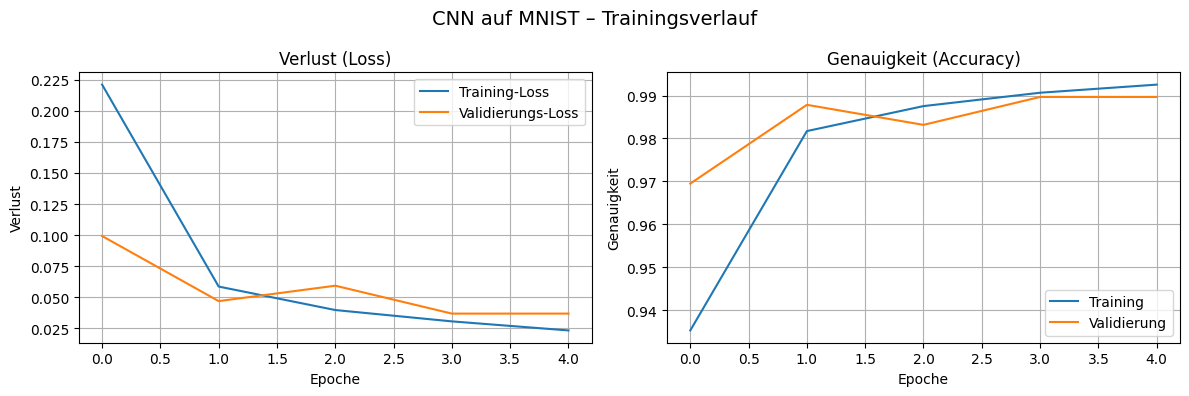

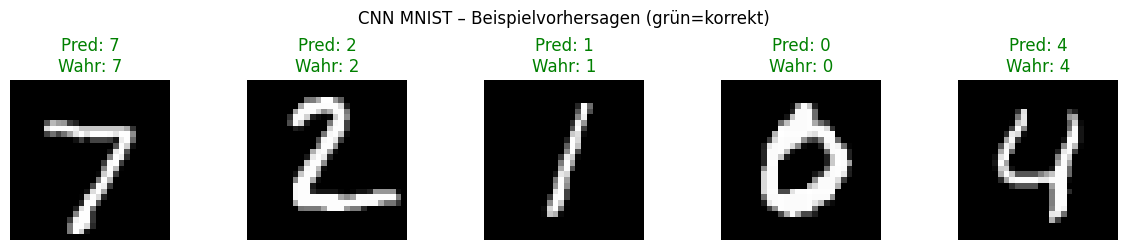

Diagramme gespeichert: A7_1_cnn_training.png, A7_1_cnn_vorhersagen.png


In [1]:
%matplotlib inline
# ============================================================
# educx GmbH – Neuronale Netze | Modul 2
# Lerntag 7: Convolutional Neural Networks (CNN)
# Niveau: Anfänger
# Aufgabe 1 von 3
# ============================================================
# Musterlösung – lauffähig in Spyder (tf_arm conda env)
# Python-Pfad: /Users/solusprime/opt/anaconda3/envs/tf_arm/bin/python
# ============================================================

import tensorflow as tf
import numpy as np
import matplotlib

import matplotlib.pyplot as plt

print("TensorFlow Version:", tf.__version__)

# ── 1. MNIST-Daten laden und vorbereiten ─────────────────────────────────────
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

# CNN erwartet Kanal-Dimension: (N, 28, 28, 1)
x_train = x_train.astype("float32")[..., np.newaxis] / 255.0
x_test  = x_test.astype("float32")[..., np.newaxis]  / 255.0
print(f"Trainingsdaten: {x_train.shape}  Testdaten: {x_test.shape}")

# ── 2. CNN-Architektur aufbauen ───────────────────────────────────────────────
modell = tf.keras.Sequential([
    tf.keras.Input(shape=(28, 28, 1)),
    # Erster Faltungsblock: 32 Filter, 3×3 Kernel, ReLU
    tf.keras.layers.Conv2D(32, (3, 3), activation="relu", name="conv_1"),
    tf.keras.layers.MaxPooling2D((2, 2), name="pool_1"),

    # Zweiter Faltungsblock: 64 Filter, 3×3 Kernel, ReLU
    tf.keras.layers.Conv2D(64, (3, 3), activation="relu", name="conv_2"),
    tf.keras.layers.MaxPooling2D((2, 2), name="pool_2"),

    # Flachdrücken und dichte Schichten
    tf.keras.layers.Flatten(name="flatten"),
    tf.keras.layers.Dense(128, activation="relu", name="dense_1"),
    tf.keras.layers.Dense(10,  activation="softmax", name="ausgabe"),
], name="MNIST_CNN")

# ── 3. Modell kompilieren ─────────────────────────────────────────────────────
modell.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)
modell.summary()

# ── 4. Training (5 Epochen) ───────────────────────────────────────────────────
print("\nStarte Training (5 Epochen)...")
history = modell.fit(
    x_train, y_train,
    epochs=5,
    batch_size=128,
    validation_split=0.1,
    verbose=1
)

# ── 5. Evaluation ─────────────────────────────────────────────────────────────
test_loss, test_acc = modell.evaluate(x_test, y_test, verbose=0)
print(f"\nTest-Verlust:     {test_loss:.4f}")
print(f"Test-Genauigkeit: {test_acc:.4f}")

# ── 6. Trainingsverlauf plotten ───────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history.history["loss"],     label="Training-Loss")
axes[0].plot(history.history["val_loss"], label="Validierungs-Loss")
axes[0].set_title("Verlust (Loss)")
axes[0].set_xlabel("Epoche")
axes[0].set_ylabel("Verlust")
axes[0].legend()
axes[0].grid(True)

axes[1].plot(history.history["accuracy"],     label="Training")
axes[1].plot(history.history["val_accuracy"], label="Validierung")
axes[1].set_title("Genauigkeit (Accuracy)")
axes[1].set_xlabel("Epoche")
axes[1].set_ylabel("Genauigkeit")
axes[1].legend()
axes[1].grid(True)

plt.suptitle("CNN auf MNIST – Trainingsverlauf", fontsize=14)
plt.tight_layout()
plt.savefig("A7_1_cnn_training.png", dpi=100)
plt.show()

# ── 7. Beispielvorhersagen anzeigen ───────────────────────────────────────────
vorhersagen = modell.predict(x_test[:5], verbose=0)
klassen     = np.argmax(vorhersagen, axis=1)

fig, axes = plt.subplots(1, 5, figsize=(12, 2.5))
for i in range(5):
    axes[i].imshow(x_test[i, :, :, 0], cmap="gray")
    farbe = "green" if klassen[i] == y_test[i] else "red"
    axes[i].set_title(f"Pred: {klassen[i]}\nWahr: {y_test[i]}", color=farbe)
    axes[i].axis("off")

plt.suptitle("CNN MNIST – Beispielvorhersagen (grün=korrekt)", fontsize=12)
plt.tight_layout()
plt.savefig("A7_1_cnn_vorhersagen.png", dpi=100)
plt.show()
print("Diagramme gespeichert: A7_1_cnn_training.png, A7_1_cnn_vorhersagen.png")


## Exercise 2

**Dataset Used:** MNIST (keras.datasets)

The following code implements the steps for this exercise. Outputs and charts are generated automatically inline.

**Ziel / Zweck:**
Das Ziel dieser Aufgabe ist es, die Funktionsweise von Faltungsfiltern (Kernels) visuell greifbar zu machen. Wir wenden manuell verschiedene Filtermatrizen (z. B. für Kantenerkennung, Weichzeichnung und Schärfung) auf ein einziges Bild an. So sehen wir genau, was im ersten Schritt eines Convolutional Neural Networks passiert, bevor das Netzwerk die optimalen Filterwerte selbständig durch Training erlernt.


### Verwendete Codes und Funktionen

| Code / Funktion | Zeile für Zeile Erklärung (Deutsch) |
|---|---|
| `from scipy.ndimage import convolve` | Importiert die `convolve`-Funktion, um eine manuelle 2D-Faltung (Matrixmultiplikation) durchzuführen. |
| `x_train[0].astype("float32")` | Wählt das erste Bild aus den Trainingsdaten aus und konvertiert es für die Berechnung in Dezimalzahlen. |
| `np.array([...], dtype="float32")` | Erstellt einen 3x3 NumPy-Array (Matrix), der als unser manueller Filter/Kernel fungiert. |
| `filter_liste = [...]` | Erstellt eine Liste von Tupeln, die den Filternamen und die dazugehörige Matrix für eine Iteration speichert. |
| `ergebnisse = []` | Initialisiert eine leere Liste, um die gefalteten Ausgabebilder später zu speichern. |
| `for name, f in filter_liste:` | Startet eine Schleife, die jeden Namen und jeden Filter (Matrix) aus der Liste durchgeht. |
| `convolve(bild, f, mode="constant", cval=0.0)` | Wendet den 3x3 Filter `f` auf das `bild` an. Ränder werden mit 0en aufgefüllt (Padding). |
| `ergebnisse.append((name, gefaltetes_bild))` | Speichert den Namen des Filters und das berechnete Bild-Ergebnis in die Liste. |
| `gefaltetes_bild.min()` / `gefaltetes_bild.max()` | Berechnet den kleinsten und größten Pixelwert des gefalteten Bildes, um die Änderung zu sehen. |
| `fig, axes = plt.subplots(1, 4, ...)` | Erstellt ein Raster von 4 Diagrammen nebeneinander (1 Originalbild + 3 Filterergebnisse). |
| `zip(axes[1:], ergebnisse)` | Verknüpft die letzten 3 leeren Diagramm-Boxen mit den 3 zuvor berechneten Filter-Ergebnissen für die Ausgabe. |
| `ax.imshow(ergebnis, cmap="gray")` | Zeigt das gefaltete Matrix-Ergebnis als Graustufenbild an. |
| `ax.set_title(...)` / `ax.axis("off")` | Setzt den Titel über das Bild und versteckt die störenden X- und Y-Achsen-Striche. |

TensorFlow Version: 2.21.0
Bild-Shape: (28, 28), Ziffer: 5
Filter 'Kantenerkennung': Min=-759.0, Max=759.0
Filter 'Weichzeichner': Min=0.0, Max=247.7
Filter 'Schärfefilter': Min=-525.0, Max=704.0


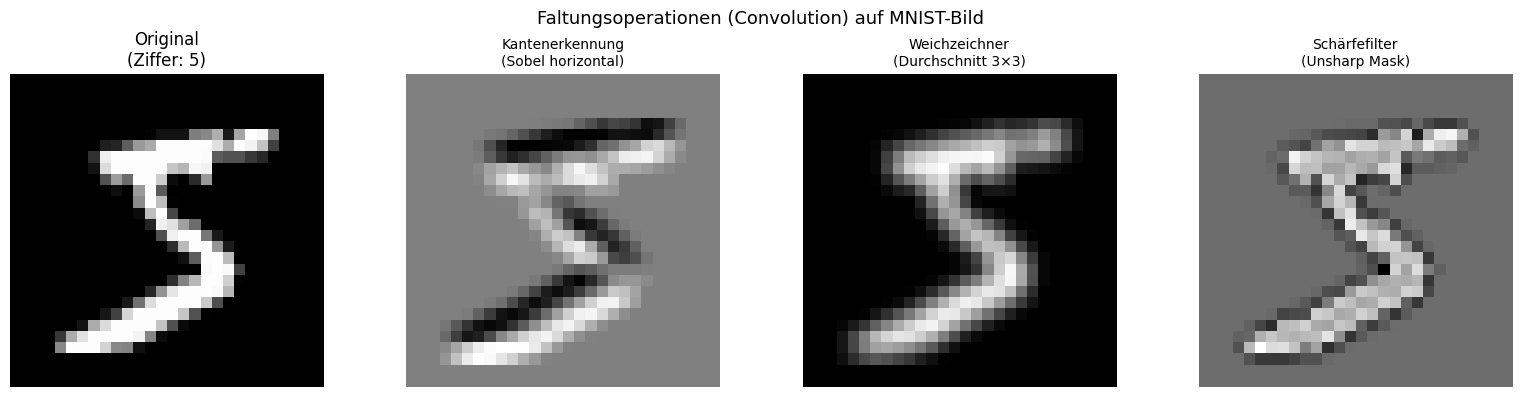

Diagramm gespeichert: A7_2_faltung_visualisiert.png

── Erklärung der Faltungsoperation ──
1. Ein Filter (Kernel) gleitet über das Bild.
2. An jeder Position wird das elementweise Produkt berechnet.
3. Die Summe der Produkte ergibt den neuen Pixelwert.
4. Der Filter ist klein (z.B. 3×3), erkennt aber lokale Muster.

Kantenerkennung: Hebt horizontale Kanten hervor (helle/dunkle Übergänge)
Weichzeichner:   Mittelt benachbarte Pixel → Rauschen wird reduziert
Schärfefilter:   Verstärkt Kontraste → Details werden betont


In [2]:
%matplotlib inline
# ============================================================
# educx GmbH – Neuronale Netze | Modul 2
# Lerntag 7: Convolutional Neural Networks (CNN)
# Niveau: Anfänger
# Aufgabe 2 von 3
# ============================================================
# Musterlösung – lauffähig in Spyder (tf_arm conda env)
# Python-Pfad: /Users/solusprime/opt/anaconda3/envs/tf_arm/bin/python
# ============================================================

import tensorflow as tf
import numpy as np
from scipy.ndimage import convolve
import matplotlib

import matplotlib.pyplot as plt

print("TensorFlow Version:", tf.__version__)

# ── 1. Ein MNIST-Bild laden ───────────────────────────────────────────────────
(x_train, y_train), _ = tf.keras.datasets.mnist.load_data()
bild = x_train[0].astype("float32")  # 28×28 Pixel
print(f"Bild-Shape: {bild.shape}, Ziffer: {y_train[0]}")

# ── 2. Filter definieren ──────────────────────────────────────────────────────

# Filter 1: Kantenerkennung (Sobel-ähnlich, horizontal)
filter_kanten = np.array([
    [-1, -1, -1],
    [ 0,  0,  0],
    [ 1,  1,  1]
], dtype="float32")

# Filter 2: Weichzeichner (Gauss-ähnlich, Durchschnitt)
filter_weich = np.array([
    [1/9, 1/9, 1/9],
    [1/9, 1/9, 1/9],
    [1/9, 1/9, 1/9]
], dtype="float32")

# Filter 3: Schärfefilter (Unsharp Mask)
filter_schaerfen = np.array([
    [ 0, -1,  0],
    [-1,  5, -1],
    [ 0, -1,  0]
], dtype="float32")

filter_liste = [
    ("Kantenerkennung\n(Sobel horizontal)", filter_kanten),
    ("Weichzeichner\n(Durchschnitt 3×3)",   filter_weich),
    ("Schärfefilter\n(Unsharp Mask)",        filter_schaerfen),
]

# ── 3. Faltung (Convolution) anwenden ────────────────────────────────────────
ergebnisse = []
for name, f in filter_liste:
    gefaltetes_bild = convolve(bild, f, mode="constant", cval=0.0)
    ergebnisse.append((name, gefaltetes_bild))
    print(f"Filter '{name.split(chr(10))[0]}': "
          f"Min={gefaltetes_bild.min():.1f}, Max={gefaltetes_bild.max():.1f}")

# ── 4. Visualisierung ─────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 4, figsize=(16, 4))

# Original
axes[0].imshow(bild, cmap="gray")
axes[0].set_title(f"Original\n(Ziffer: {y_train[0]})")
axes[0].axis("off")

# Gefaltete Bilder
for ax, (name, ergebnis) in zip(axes[1:], ergebnisse):
    ax.imshow(ergebnis, cmap="gray")
    ax.set_title(name, fontsize=10)
    ax.axis("off")

plt.suptitle("Faltungsoperationen (Convolution) auf MNIST-Bild", fontsize=13)
plt.tight_layout()
plt.savefig("A7_2_faltung_visualisiert.png", dpi=100)
plt.show()
print("Diagramm gespeichert: A7_2_faltung_visualisiert.png")

# ── 5. Erklärung der Faltungsoperation ───────────────────────────────────────
print("\n── Erklärung der Faltungsoperation ──")
print("1. Ein Filter (Kernel) gleitet über das Bild.")
print("2. An jeder Position wird das elementweise Produkt berechnet.")
print("3. Die Summe der Produkte ergibt den neuen Pixelwert.")
print("4. Der Filter ist klein (z.B. 3×3), erkennt aber lokale Muster.")
print()
print("Kantenerkennung: Hebt horizontale Kanten hervor (helle/dunkle Übergänge)")
print("Weichzeichner:   Mittelt benachbarte Pixel → Rauschen wird reduziert")
print("Schärfefilter:   Verstärkt Kontraste → Details werden betont")


## Exercise 3

**Dataset Used:** MNIST (keras.datasets)

The following code implements the steps for this exercise. Outputs and charts are generated automatically inline.

**Ziel / Zweck:**
In dieser Aufgabe möchten wir in das Innere unseres trainierten CNNs blicken. Der Zweck ist es, die sogenannten „Feature Maps“ (Merkmalskarten) zu extrahieren und zu visualisieren, die das Netzwerk während der Analyse erzeugt. Dadurch wird verständlicher, auf welche Muster und Kanten das neuronale Netz achtet, wenn es Entscheidungen trifft.


### Verwendete Codes und Funktionen

| Code / Funktion | Zeile für Zeile Erklärung (Deutsch) |
|---|---|
| `import math` | Importiert mathematische Standardfunktionen wie Aufrunden (ceil). |
| `x_train[:5000]` | Beschneidet die Trainingsdaten auf 5000 Bilder, um das Training für dieses Beispiel zu beschleunigen. |
| `tf.keras.Model(inputs=..., outputs=...)` | Erstellt ein neues, funktionales Keras-Modell, das bestimmte Zwischenschichten abgreift. |
| `modell.input` | Greift auf den Eingangstensor des zuvor erstellten `modell` zu. |
| `modell.get_layer("conv_1").output` | Sucht die Schicht mit dem Namen `conv_1` und nutzt deren Ausgabe als Output für das neue Modell. |
| `x_test[0:1]` | Extrahiert das exakt erste Testbild (die Slicing-Syntax `0:1` erhält die Form des Tensors: 1x28x28x1). |
| `feature_map_modell.predict(probe_bild)` | Lässt das Eingabebild durch das Extraktor-Modell laufen und gibt die Aktivierungen der Convolution-Schicht zurück. |
| `feature_maps.shape[-1]` | Liest das letzte Element aus der Tensor-Form ab (gibt die Anzahl der Filter / Kanäle zurück, hier 16). |
| `math.ceil(n_filter / n_spalten)` | Berechnet die Anzahl der benötigten Plot-Zeilen. Teilt die Filter durch die Spaltenzahl und rundet auf. |
| `for col in range(n_spalten):` | Iteriert über die Spalten der ersten Zeile im Plot, um das Originalbild darzustellen. |
| `for i in range(n_filter):` | Iteriert von 0 bis 15, um jede der 16 Feature Maps zu verarbeiten. |
| `zeile = i // n_spalten + 1` | Berechnet mathematisch die korrekte Zeile im Plot für den Index `i` (mittels Ganzzahldivision). |
| `spalte = i % n_spalten` | Berechnet die korrekte Spalte im Plot für den Index `i` (mittels Modulo-Operation). |
| `fm = feature_maps[0, :, :, i]` | Extrahiert aus dem 4D-Tensor exakt die `i`-te Feature Map des ersten Bildes als 2D-Matrix. |
| `axes[zeile, spalte].imshow(fm, cmap="viridis")` | Zeichnet die Feature Map mit einem Farbverlauf ("viridis", zeigt hohe und niedrige Werte deutlich an). |
| `for i in range(n_filter, n_zeilen * n_spalten):` | Iteriert über restliche, leere Diagramm-Plätze und schaltet deren Achsen ab (`axis("off")`). |
| `fm.min()`, `fm.max()`, `fm.mean()` | Berechnen das Minimum, das Maximum und den Durchschnitt der Aktivierungswerte der jeweiligen Matrix. |

TensorFlow Version: 2.21.0
Trainiere kleines CNN...
Epoch 1/3
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.6942 - loss: 1.0351 - val_accuracy: 0.8780 - val_loss: 0.4110
Epoch 2/3
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9204 - loss: 0.2748 - val_accuracy: 0.9220 - val_loss: 0.2632
Epoch 3/3
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9480 - loss: 0.1798 - val_accuracy: 0.9440 - val_loss: 0.2123
Training abgeschlossen.

Feature-Map-Shape (conv_1): (1, 28, 28, 16)


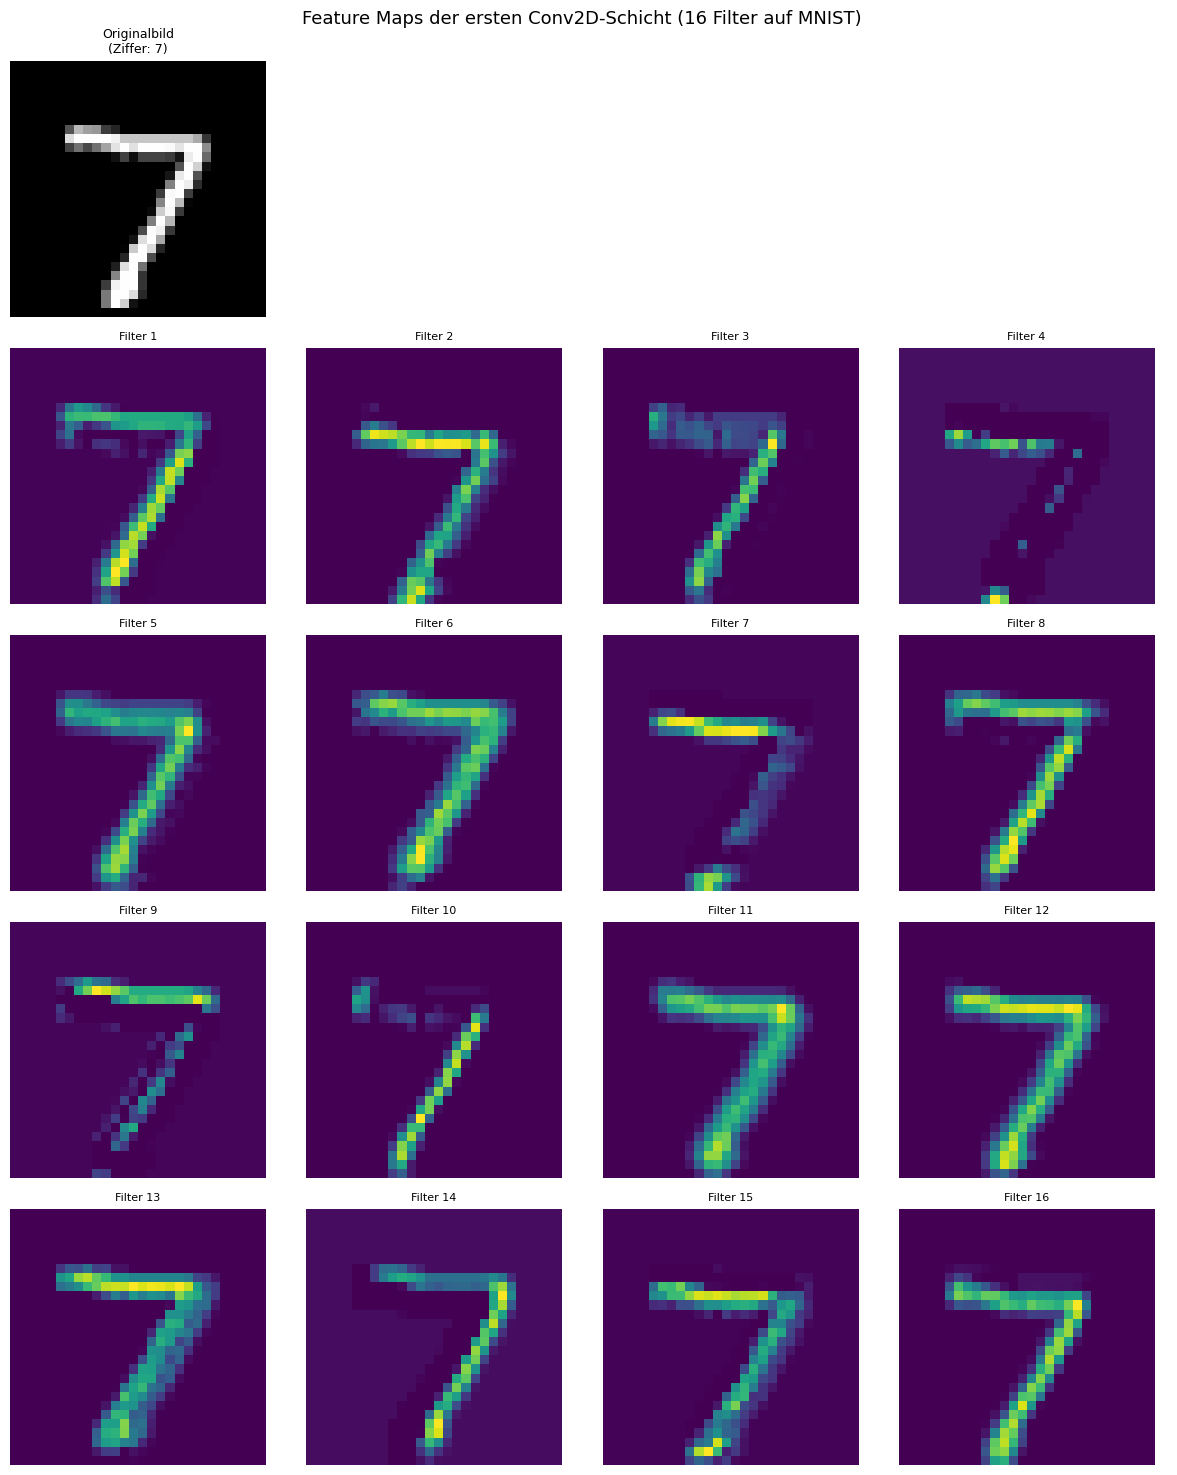

Diagramm gespeichert: A7_3_feature_maps.png

Statistiken der 16 Feature Maps:
  Filter  1: min=0.000, max=0.512, mittelwert=0.041
  Filter  2: min=0.000, max=0.393, mittelwert=0.029
  Filter  3: min=0.000, max=0.317, mittelwert=0.016
  Filter  4: min=0.000, max=0.143, mittelwert=0.007
  Filter  5: min=0.000, max=0.633, mittelwert=0.052
  Filter  6: min=0.000, max=0.581, mittelwert=0.056
  Filter  7: min=0.000, max=0.616, mittelwert=0.037
  Filter  8: min=0.000, max=0.598, mittelwert=0.046
  Filter  9: min=0.000, max=0.311, mittelwert=0.017
  Filter 10: min=0.000, max=0.488, mittelwert=0.019
  Filter 11: min=0.000, max=1.029, mittelwert=0.094
  Filter 12: min=0.000, max=0.694, mittelwert=0.061
  Filter 13: min=0.000, max=0.539, mittelwert=0.046
  Filter 14: min=0.000, max=0.375, mittelwert=0.029
  Filter 15: min=0.000, max=0.488, mittelwert=0.036
  Filter 16: min=0.000, max=0.505, mittelwert=0.037


In [3]:
%matplotlib inline
# ============================================================
# educx GmbH – Neuronale Netze | Modul 2
# Lerntag 7: Convolutional Neural Networks (CNN)
# Niveau: Anfänger
# Aufgabe 3 von 3
# ============================================================
# Musterlösung – lauffähig in Spyder (tf_arm conda env)
# Python-Pfad: /Users/solusprime/opt/anaconda3/envs/tf_arm/bin/python
# ============================================================

import tensorflow as tf
import numpy as np
import matplotlib

import matplotlib.pyplot as plt
import math

print("TensorFlow Version:", tf.__version__)

# ── 1. MNIST laden und CNN trainieren ─────────────────────────────────────────
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()
x_train = x_train[:5000].astype("float32")[..., np.newaxis] / 255.0
x_test  = x_test.astype("float32")[..., np.newaxis]         / 255.0

# Wir nutzen hier die Functional API, damit get_layer().output in Keras 3 sicher funktioniert
inputs = tf.keras.Input(shape=(28, 28, 1), name="eingabe")
x = tf.keras.layers.Conv2D(16, (3, 3), activation="relu", padding="same", name="conv_1")(inputs)
x = tf.keras.layers.MaxPooling2D((2, 2), name="pool_1")(x)
x = tf.keras.layers.Conv2D(32, (3, 3), activation="relu", padding="same", name="conv_2")(x)
x = tf.keras.layers.MaxPooling2D((2, 2), name="pool_2")(x)
x = tf.keras.layers.Flatten(name="flatten")(x)
x = tf.keras.layers.Dense(64, activation="relu")(x)
outputs = tf.keras.layers.Dense(10, activation="softmax")(x)

modell = tf.keras.Model(inputs=inputs, outputs=outputs, name="Feature_Map_CNN")

modell.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)
print("Trainiere kleines CNN...")
modell.fit(x_train, y_train[:5000], epochs=3, batch_size=64,
           validation_split=0.1, verbose=1)
print("Training abgeschlossen.")

# ── 2. Modell für Feature-Map-Extraktion erstellen ────────────────────────────
# Zwischenmodell: gibt Ausgabe der ersten Conv-Schicht zurück
feature_map_modell = tf.keras.Model(
    inputs=modell.input,
    outputs=modell.get_layer("conv_1").output,
    name="Feature_Map_Extraktor"
)

# ── 3. Feature Maps für ein Beispielbild extrahieren ─────────────────────────
# Erstes Testbild
probe_bild = x_test[0:1]           # Shape: (1, 28, 28, 1)
feature_maps = feature_map_modell.predict(probe_bild, verbose=0)
print(f"\nFeature-Map-Shape (conv_1): {feature_maps.shape}")
# → (1, 28, 28, 16): 16 verschiedene Feature Maps für das eine Bild

# ── 4. Feature Maps visualisieren ────────────────────────────────────────────
n_filter = feature_maps.shape[-1]     # = 16
n_spalten = 4
n_zeilen  = math.ceil(n_filter / n_spalten)

fig, axes = plt.subplots(n_zeilen + 1, n_spalten, figsize=(n_spalten * 3, (n_zeilen + 1) * 3))

# Originalbild in der ersten Zeile
for col in range(n_spalten):
    if col == 0:
        axes[0, col].imshow(probe_bild[0, :, :, 0], cmap="gray")
        axes[0, col].set_title(f"Originalbild\n(Ziffer: {y_test[0]})", fontsize=9)
    else:
        axes[0, col].axis("off")
axes[0, 0].axis("off")
axes[0, 0].imshow(probe_bild[0, :, :, 0], cmap="gray")

# Feature Maps in den weiteren Zeilen
for i in range(n_filter):
    zeile  = i // n_spalten + 1
    spalte = i  % n_spalten
    fm = feature_maps[0, :, :, i]
    axes[zeile, spalte].imshow(fm, cmap="viridis")
    axes[zeile, spalte].set_title(f"Filter {i+1}", fontsize=8)
    axes[zeile, spalte].axis("off")

# Leere Subplots ausblenden
for i in range(n_filter, n_zeilen * n_spalten):
    zeile  = i // n_spalten + 1
    spalte = i  % n_spalten
    axes[zeile, spalte].axis("off")

plt.suptitle("Feature Maps der ersten Conv2D-Schicht (16 Filter auf MNIST)", fontsize=13)
plt.tight_layout()
plt.savefig("A7_3_feature_maps.png", dpi=100)
plt.show()
print("Diagramm gespeichert: A7_3_feature_maps.png")

# ── 5. Statistiken der Feature Maps ──────────────────────────────────────────
print(f"\nStatistiken der 16 Feature Maps:")
for i in range(n_filter):
    fm = feature_maps[0, :, :, i]
    print(f"  Filter {i+1:2d}: min={fm.min():.3f}, max={fm.max():.3f}, "
          f"mittelwert={fm.mean():.3f}")
